$$
y'=x^2+y
$$

In [4]:
from scipy.integrate import solve_ivp
def f(x, y):
    return x**2+y
res = solve_ivp(fun=f,t_span=(0,100), y0=[1],dense_output=True)
print(res.sol)

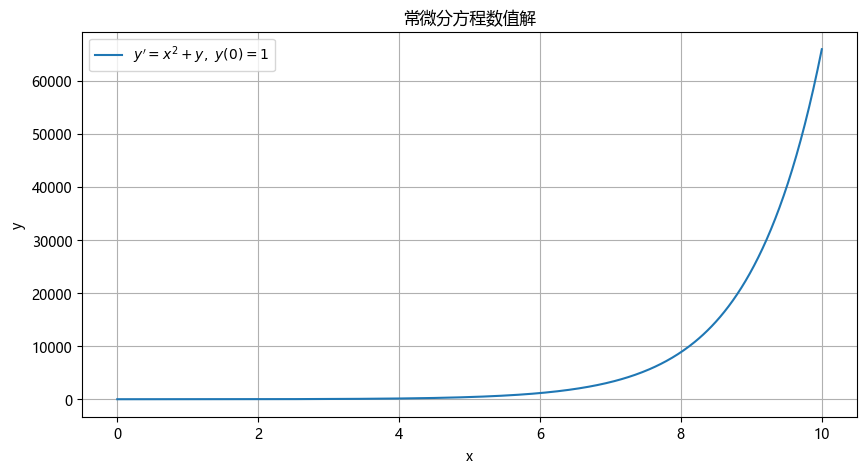

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 中文字体适配
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# 在解区间上采样并绘图
x_vals = np.linspace(0, 10, 500)   # 先画 0~10（到 100 增长太快会炸）
y_vals = res.sol(x_vals)[0]        # res.sol 返回 (1, n) 数组

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, label=r"$y'=x^2+y,\ y(0)=1$")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.title("常微分方程数值解")
plt.show()

$$
y''+4y'+29y=x
$$
令$u_1=y,u_2=y'$:
$$
u_1'=y'=u_2
$$
$$
y''=u_2'=-4y'-29y+x=-4u_1'-29u_1+x
$$

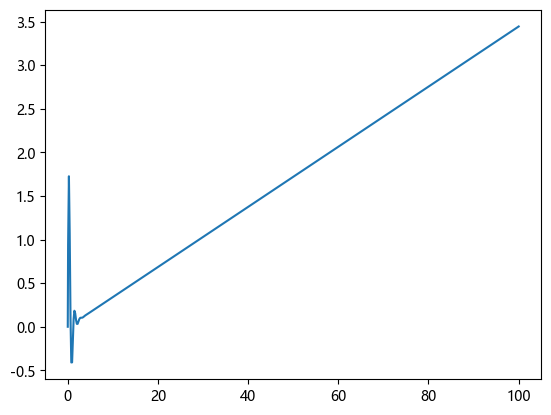

In [6]:
def f(x, u):
    return [
        u[1],
        -4*u[1]-29*u[0]+x
    ]
res = solve_ivp(fun=f,t_span=(0,100), y0=[0,15],dense_output=True)

x_vals = np.linspace(0, 10, 500)   # 先画 0~10（到 100 增长太快会炸）
y_vals = res.sol(x_vals)[0]        # res.sol 返回 (1, n) 数组


plt.plot(res.t, res.y[0])
plt.show()

Logistic模型
$$
\frac{dP}{dt}=r\left(1-\frac{P}{P_m}\right)P,\quad P(0)=P_0 \\
P(t)=\frac{P_m}{1+\left(\frac{P_m}{P_0}-1\right)e^{-rt}}
$$



认识人口数量的变化规律，建立人口模型，做出较准确的预报，是有效控制人口增长的前提。利用表给出的近 2 个世纪的美国人口统计数据（单位：百万人），建立人口预测模型，最后用它预报 2010 年美国的人口。

| 年   | 人口 | 年   | 人口 | 年   | 人口 |
| --- | --- | --- | --- | --- | --- |
| 1790 | 3.9  | 1870 | 38.6 | 1950 | 150.7 |
| 1800 | 5.3  | 1880 | 50.2 | 1960 | 179.3 |
| 1810 | 7.2  | 1890 | 62.9 | 1970 | 204   |
| 1820 | 9.6  | 1900 | 76   | 1980 | 226.5 |
| 1830 | 12.9 | 1910 | 92   | 1990 | 251.4 |
| 1840 | 17.1 | 1920 | 106.5| 2000 | 281.4 |
| 1850 | 23.2 | 1930 | 123.2|      |       |
| 1860 | 31.4 | 1940 | 131.7|      |       |

In [7]:
from scipy.optimize import curve_fit
import numpy as np

years = np.array(
    [1790, 1800, 1810, 1820, 1830, 1840, 1850, 1860, 1870, 1880, 1890, 1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000]
)
population = np.array(
    [3.9, 5.3, 7.2, 9.6, 12.9, 17.1, 23.2, 31.4, 38.6, 50.2, 62.9, 76, 92, 106.5, 123.2, 131.7, 150.7, 179.3, 204, 226.5, 251.4, 281.4]
)

years = years-np.min(years)

def f(x, pm, p0, r):
    return pm/(1+(pm/p0-1)*np.exp(-1*r*x))

popt, _ = curve_fit(
    f=f,
    xdata=years,
    ydata=population,
    bounds=[[300, 0, 0],     # 下界
        [1000, 100, 1]]   # 上界
)

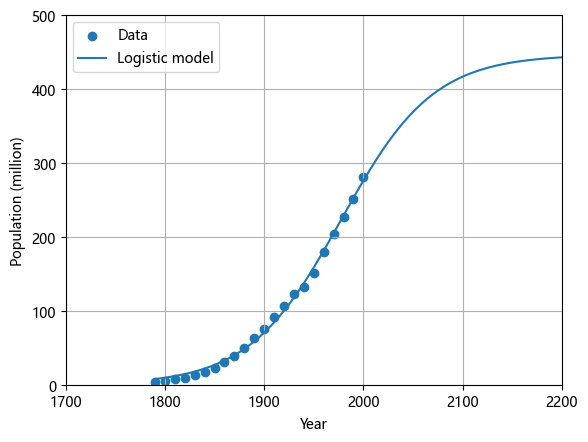

: 

In [ ]:
import matplotlib.pyplot as plt

# 恢复真实年份
real_years = years + 1790


x_fit = np.linspace(
    years.min(),
    years.max()+200,
    300
)

y_fit = f(
    x_fit,
    *popt
)


plt.scatter(
    real_years,
    population,
    label="Data"
)


plt.plot(
    x_fit + 1790,
    y_fit,
    label="Logistic model"
)
plt.xlim(1700, 2200)
plt.ylim(0, 500)
plt.xlabel("Year")
plt.ylabel("Population (million)")

plt.legend()
plt.grid()

plt.show()